In [ ]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from src.model import SimpleCNN
from src.train import train_one_epoch, evaluate
from src.evaluate import collect_predictions, confusion_matrix, per_class_accuracy

import os
os.makedirs('../results/figures', exist_ok=True)

plt.rcParams['figure.figsize'] = (10, 5)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

Device: cpu
PyTorch: 2.14.0+cpu


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),  # MNIST mean/std
])

train_dataset = datasets.MNIST(
    root='../data', train=True, download=True, transform=transform
)
test_dataset = datasets.MNIST(
    root='../data', train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples:  {len(test_dataset)}")

100%|██████████| 9.91M/9.91M [00:48<00:00, 205kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 98.7kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.19MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.5MB/s]

Train samples: 60000
Test samples:  10000


FileNotFoundError: [Errno 2] No such file or directory: '../results/figures/01_samples.png'

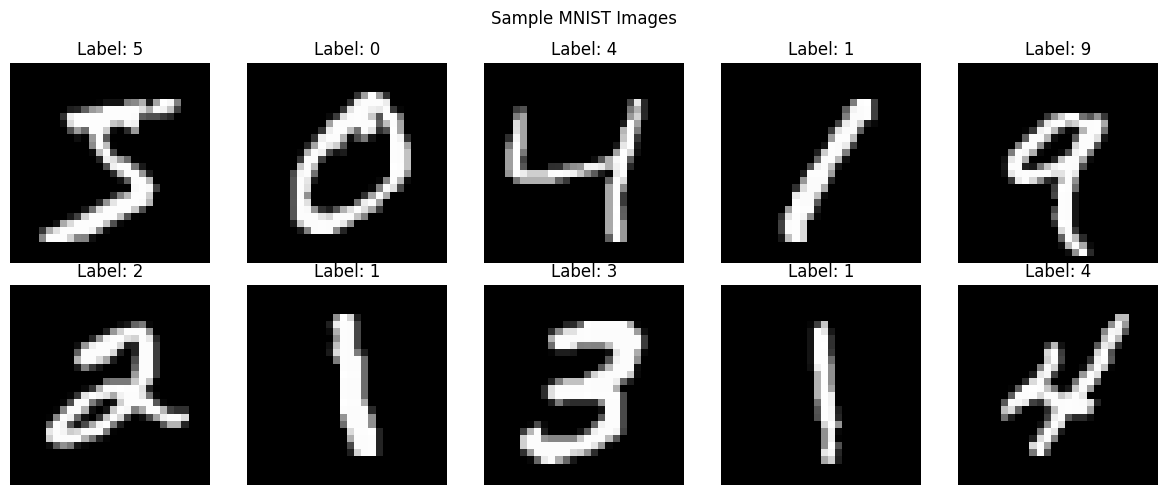

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f"Label: {label}")
    ax.axis('off')
plt.suptitle('Sample MNIST Images')
plt.tight_layout()
plt.savefig('../results/figures/01_samples.png', dpi=150)
plt.show()

In [4]:
model = SimpleCNN(num_classes=10, dropout=0.25).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters:     421,642
Trainable parameters: 421,642


In [5]:
num_epochs = 5
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    print(f"Epoch {epoch}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

Epoch 1/5 | Train Loss: 0.1610, Train Acc: 0.9498 | Test Loss: 0.0458, Test Acc: 0.9845
Epoch 2/5 | Train Loss: 0.0525, Train Acc: 0.9845 | Test Loss: 0.0414, Test Acc: 0.9861
Epoch 3/5 | Train Loss: 0.0392, Train Acc: 0.9879 | Test Loss: 0.0302, Test Acc: 0.9902
Epoch 4/5 | Train Loss: 0.0294, Train Acc: 0.9905 | Test Loss: 0.0273, Test Acc: 0.9908
Epoch 5/5 | Train Loss: 0.0243, Train Acc: 0.9919 | Test Loss: 0.0244, Test Acc: 0.9917


FileNotFoundError: [Errno 2] No such file or directory: '../results/figures/02_training_curves.png'

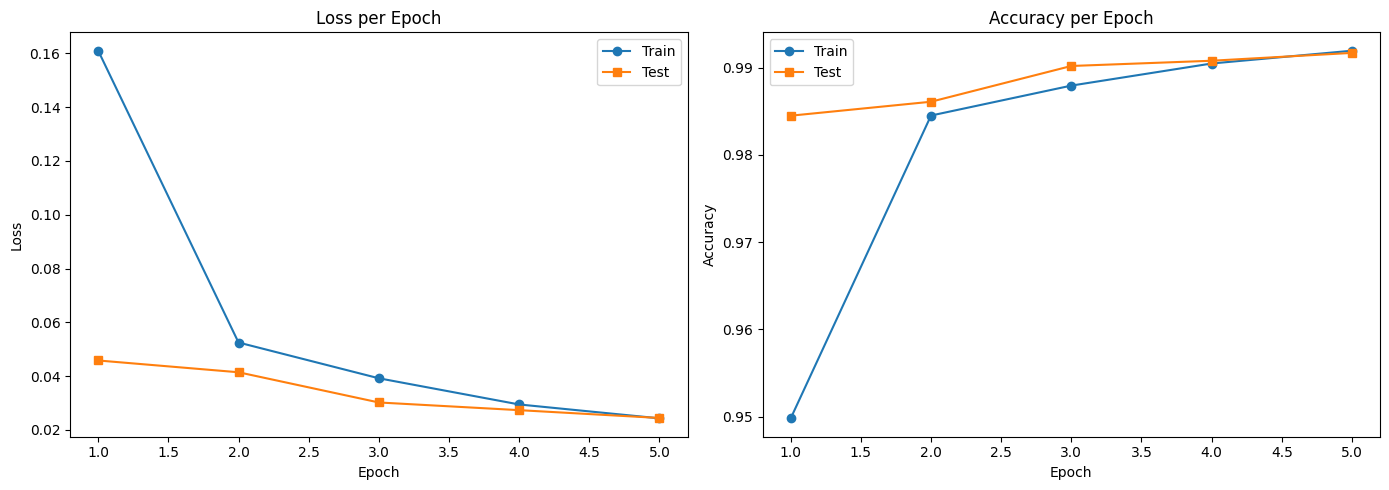

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, num_epochs + 1), history['train_loss'], 'o-', label='Train')
axes[0].plot(range(1, num_epochs + 1), history['test_loss'], 's-', label='Test')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(range(1, num_epochs + 1), history['train_acc'], 'o-', label='Train')
axes[1].plot(range(1, num_epochs + 1), history['test_acc'], 's-', label='Test')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/figures/02_training_curves.png', dpi=150)
plt.show()

In [8]:
import json

# Save model weights
torch.save(model.state_dict(), '../results/mnist_cnn.pt')

# Save training history
with open('../results/training_history.json', 'w') as f:
    json.dump(history, f, indent=2)

print("Model and history saved.")
print(f"Final test accuracy: {history['test_acc'][-1]:.4f}")

Model and history saved.
Final test accuracy: 0.9917


In [9]:
images, labels, preds = collect_predictions(model, test_loader, device)

print(f"Total test samples: {len(labels)}")
print(f"Correct: {(labels == preds).sum()}")
print(f"Incorrect: {(labels != preds).sum()}")
print(f"Accuracy: {(labels == preds).mean():.4f}")

Total test samples: 10000
Correct: 9917
Incorrect: 83
Accuracy: 0.9917


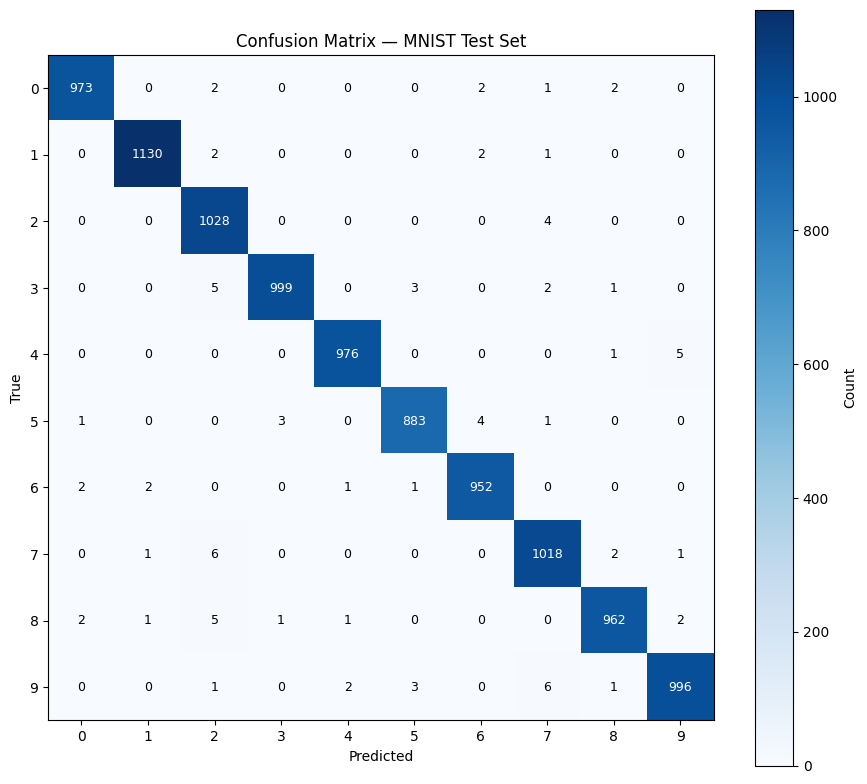

In [10]:
cm = confusion_matrix(labels, preds, num_classes=10)

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(range(10))
ax.set_yticklabels(range(10))
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix — MNIST Test Set')

# Annotate each cell
for i in range(10):
    for j in range(10):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, cm[i, j], ha='center', va='center', color=color, fontsize=9)

plt.colorbar(im, ax=ax, label='Count')
plt.tight_layout()
plt.savefig('../results/figures/03_confusion_matrix.png', dpi=150)
plt.show()

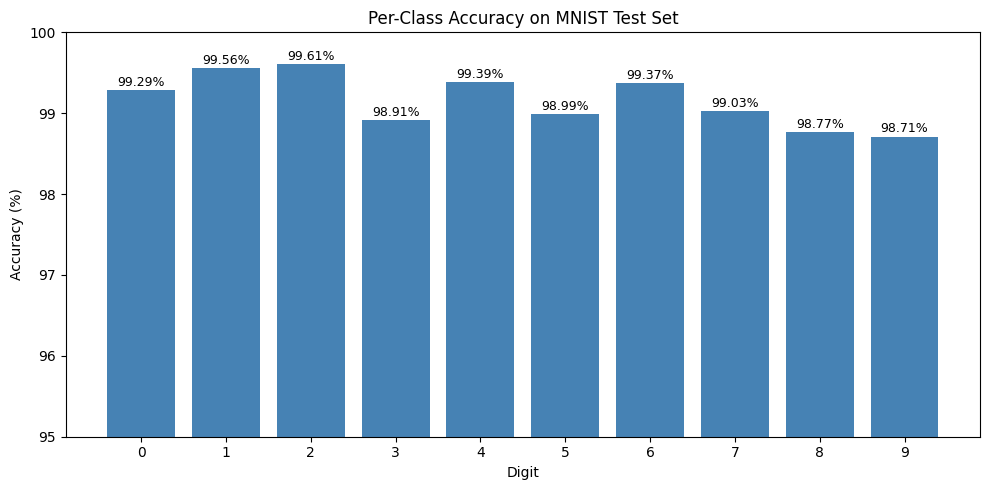

Digit 0: 99.29%
Digit 1: 99.56%
Digit 2: 99.61%
Digit 3: 98.91%
Digit 4: 99.39%
Digit 5: 98.99%
Digit 6: 99.37%
Digit 7: 99.03%
Digit 8: 98.77%
Digit 9: 98.71%


In [11]:
per_class = per_class_accuracy(cm)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(10), per_class * 100, color='steelblue')
ax.set_xticks(range(10))
ax.set_xlabel('Digit')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Class Accuracy on MNIST Test Set')
ax.set_ylim(95, 100)

for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.05,
            f"{height:.2f}%", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../results/figures/04_per_class_accuracy.png', dpi=150)
plt.show()

for i, acc in enumerate(per_class):
    print(f"Digit {i}: {acc * 100:.2f}%")

Total misclassified: 83


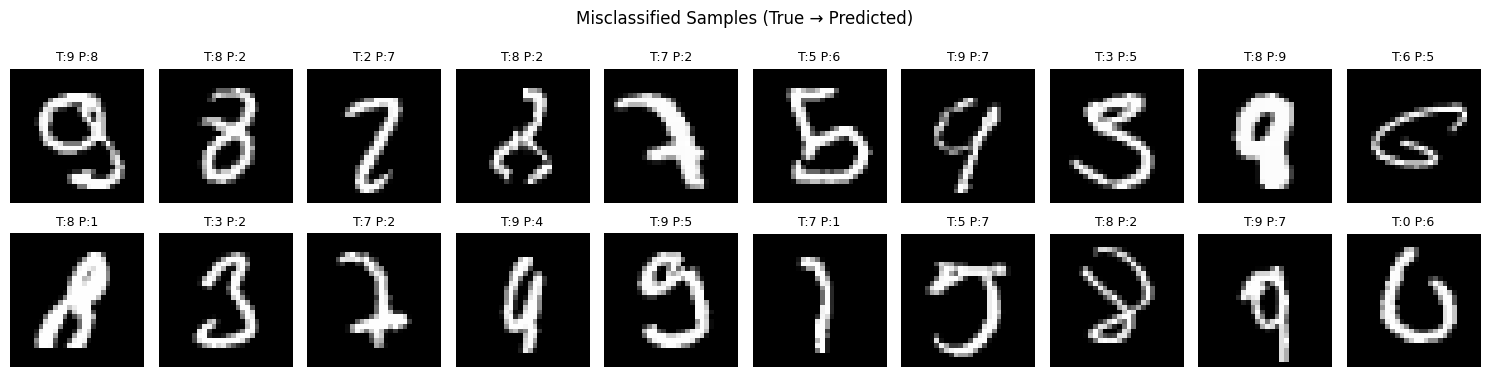

In [12]:
wrong_idx = np.where(labels != preds)[0]
print(f"Total misclassified: {len(wrong_idx)}")

n_show = min(20, len(wrong_idx))
fig, axes = plt.subplots(2, 10, figsize=(15, 4))
for i, idx in enumerate(wrong_idx[:n_show]):
    ax = axes.flat[i]
    ax.imshow(images[idx].squeeze(), cmap='gray')
    ax.set_title(f"T:{labels[idx]} P:{preds[idx]}", fontsize=9)
    ax.axis('off')

plt.suptitle('Misclassified Samples (True → Predicted)', fontsize=12)
plt.tight_layout()
plt.savefig('../results/figures/05_misclassified.png', dpi=150)
plt.show()

In [13]:
# Find top confused pairs (ignoring diagonal)
confused_pairs = []
for i in range(10):
    for j in range(10):
        if i != j and cm[i, j] > 0:
            confused_pairs.append((i, j, cm[i, j]))

confused_pairs.sort(key=lambda x: -x[2])

print("Top-10 most confused pairs (True → Predicted):")
print("=" * 40)
for true_d, pred_d, count in confused_pairs[:10]:
    print(f"  {true_d} → {pred_d}: {count} times")

Top-10 most confused pairs (True → Predicted):
  7 → 2: 6 times
  9 → 7: 6 times
  3 → 2: 5 times
  4 → 9: 5 times
  8 → 2: 5 times
  2 → 7: 4 times
  5 → 6: 4 times
  3 → 5: 3 times
  5 → 3: 3 times
  9 → 5: 3 times


In [14]:
error_analysis = {
    "test_accuracy": float((labels == preds).mean()),
    "total_misclassified": int((labels != preds).sum()),
    "per_class_accuracy": {str(i): float(per_class[i]) for i in range(10)},
    "top_confused_pairs": [
        {"true": int(t), "predicted": int(p), "count": int(c)}
        for t, p, c in confused_pairs[:10]
    ],
}

with open('../results/error_analysis.json', 'w') as f:
    json.dump(error_analysis, f, indent=2)

print("Error analysis saved.")

Error analysis saved.
